# Gene Usage Batch-Correction Benchmark on AIRR COVID-19 (HF)

This notebook benchmarks batch correction on real data from `datasets/isalgo/airr_covid19`.

Pipeline:
1. Download/cache dataset in `notebooks/assets/large`.
2. Load metadata and repertoires with `RepertoireDataset.from_folder_polars(...)`.
3. Compute VJ usage correction (`compute_batch_corrected_gene_usage`).
4. Reproduce segment-usage style analyses: PCA, batch separability metrics, clustermaps, highlighted genes.
5. Re-run after `resample_to_gene_usage` and `filter_functional`.
6. Report final sample/batch/locus stats.

In [1]:
import importlib.metadata as _meta
import sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "pandas", "matplotlib", "scipy", "polars"]:
    try:
        print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError:
        pass

# If needed, uncomment and run once:
# %pip install -q huggingface_hub datasets polars seaborn scikit-learn umap-learn

from __future__ import annotations

from pathlib import Path
import importlib
import sys
import time
import tracemalloc
import pickle
from concurrent.futures import ThreadPoolExecutor
from collections import Counter

# Ensure local repository sources are imported (not a stale site-packages install).
repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

try:
    from umap import UMAP as UMAPReducer
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('umap-learn not installed — UMAP plots will be skipped. Run: pip install umap-learn')

from mir.common.parser import VDJtoolsParser
from mir.common.repertoire_dataset import RepertoireDataset
from mir.common.sampling import resample_to_gene_usage
from mir.common.filter import filter_functional
from mir.utils.notebook_assets import ensure_airr_covid19, notebook_large_assets_root
import mir.basic.gene_usage as gene_usage_module
importlib.reload(gene_usage_module)
from mir.basic.gene_usage import compute_batch_corrected_gene_usage, marginalize_batch_corrected_gene_usage

try:
    import psutil
except Exception:
    psutil = None

sns.set_theme(style='whitegrid', context='notebook')

# Publication-quality matplotlib style (Nature/Science aesthetics)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.grid": False,
})


Python 3.11.15
  mirpy-lib: 1.1.1
  numpy: 2.4.6
  pandas: 2.3.3
  matplotlib: 3.10.9
  scipy: 1.17.1
  polars: 1.41.2


In [2]:
asset_root = notebook_large_assets_root(repo_root)

hf_t0 = time.perf_counter()
hf_local_dir = ensure_airr_covid19(repo_root)
hf_t1 = time.perf_counter()

hf_elapsed_s = hf_t1 - hf_t0
print(f'Using dataset at: {hf_local_dir}')
print(f'HF dataset ready in {hf_elapsed_s:.2f} seconds')

hf_local_dir

Using dataset at: /Users/mikesh/vcs/code/mirpy/notebooks/assets/large/airr_covid19
HF dataset ready in 2.85 seconds


PosixPath('/Users/mikesh/vcs/code/mirpy/notebooks/assets/large/airr_covid19')

In [3]:
# Locate metadata file (robust to internal folder layout)
meta_candidates = sorted(hf_local_dir.rglob('metadata.tsv')) + sorted(hf_local_dir.rglob('*metadata*.tsv'))
if not meta_candidates:
    raise FileNotFoundError('Could not locate metadata TSV in the downloaded dataset directory.')

metadata_path = meta_candidates[0]
data_root = metadata_path.parent
print('metadata_path =', metadata_path)
print('data_root =', data_root)

meta_pl = pl.read_csv(metadata_path, separator='	', infer_schema_length=20_000)
print('metadata columns:', meta_pl.columns)

required_cols = {'sample_id', 'batch_id', 'file_name', 'locus'}
missing_cols = required_cols.difference(set(meta_pl.columns))
if missing_cols:
    raise ValueError(f'Metadata is missing required columns: {sorted(missing_cols)}')

meta_pl.head()

metadata_path = /Users/mikesh/vcs/code/mirpy/notebooks/assets/large/airr_covid19/metadata.tsv
data_root = /Users/mikesh/vcs/code/mirpy/notebooks/assets/large/airr_covid19
metadata columns: ['file_name', 'reads', 'clonotypes', 'singletons', 'doubletons', 'file_id', 'sequencing_date', 'batch_id', 'R1', 'R2', 'sample_id', 'COVID_status', 'project_name', 'COVID_IgG', 'COVID_IgM', 'COVID_PCR', 'HLA-A_1', 'HLA-A_2', 'HLA-B_1', 'HLA-B_2', 'HLA-C_1', 'HLA-C_2', 'HLA-DPB1_1', 'HLA-DPB1_2', 'HLA-DQB1_1', 'HLA-DQB1_2', 'HLA-DRB1_1', 'HLA-DRB1_2', 'donor_id', 'subsequent_sequencing', 'HLA-DRB4_1', 'HLA-DRB3_1', 'HLA-DRB5_1', 'locus', 'is_bad_reseq']


file_name,reads,clonotypes,singletons,doubletons,file_id,sequencing_date,batch_id,R1,R2,sample_id,COVID_status,project_name,COVID_IgG,COVID_IgM,COVID_PCR,HLA-A_1,HLA-A_2,HLA-B_1,HLA-B_2,HLA-C_1,HLA-C_2,HLA-DPB1_1,HLA-DPB1_2,HLA-DQB1_1,HLA-DQB1_2,HLA-DRB1_1,HLA-DRB1_2,donor_id,subsequent_sequencing,HLA-DRB4_1,HLA-DRB3_1,HLA-DRB5_1,locus,is_bad_reseq
str,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""020000010808_S3_L001.TRA.vdjto…",1114519,8162,1072,528,"""020000010808_S3_L001""","""2020 10 19""","""2020/10_FMBA_NovaSeq5""","""020000010808_S3_L001_R1_001.fa…","""020000010808_S3_L001_R2_001.fa…","""020000010808""","""COVID""","""FMBA_DNA""","""yes""","""no""","""negative""","""A*02:05""","""A*24:02""","""B*35:02""","""B*50:01""","""C*04:01""","""C*06:02""","""DPB1*02:01""","""DPB1*04:02""","""DQB1*03:01""","""DQB1*05:02""","""DRB1*11:04""","""DRB1*16:01""","""020000010""",null,null,null,null,"""TRA""",null
"""020000010808_S3_L001.TRB.vdjto…",623811,4324,491,263,"""020000010808_S3_L001""","""2020 10 19""","""2020/10_FMBA_NovaSeq5""","""020000010808_S3_L001_R1_001.fa…","""020000010808_S3_L001_R2_001.fa…","""020000010808""","""COVID""","""FMBA_DNA""","""yes""","""no""","""negative""","""A*02:05""","""A*24:02""","""B*35:02""","""B*50:01""","""C*04:01""","""C*06:02""","""DPB1*02:01""","""DPB1*04:02""","""DQB1*03:01""","""DQB1*05:02""","""DRB1*11:04""","""DRB1*16:01""","""020000010""",null,null,null,null,"""TRB""",null
"""020000110808_S14_L001.TRA.vdjt…",14936089,23583,1240,505,"""020000110808_S14_L001""","""2020 09 05""","""2020/09_FMBA_NovaSeq_DNA""","""020000110808_S14_L001_R1_001.f…","""020000110808_S14_L001_R2_001.f…","""020000110808""","""COVID""","""FMBA_DNA""","""yes""","""yes""","""negative""","""A*03:01""","""A*11:01""","""B*18:01""","""B*35:01""","""C*04:01""","""C*12:03""","""DPB1*04:02""","""DPB1*11:01""","""DQB1*05:01""","""DQB1*06:02""","""DRB1*01:01""","""DRB1*15:01""","""020000110""",null,null,null,null,"""TRA""",null
"""020000110808_S14_L001.TRB.vdjt…",13119545,13264,573,219,"""020000110808_S14_L001""","""2020 09 05""","""2020/09_FMBA_NovaSeq_DNA""","""020000110808_S14_L001_R1_001.f…","""020000110808_S14_L001_R2_001.f…","""020000110808""","""COVID""","""FMBA_DNA""","""yes""","""yes""","""negative""","""A*03:01""","""A*11:01""","""B*18:01""","""B*35:01""","""C*04:01""","""C*12:03""","""DPB1*04:02""","""DPB1*11:01""","""DQB1*05:01""","""DQB1*06:02""","""DRB1*01:01""","""DRB1*15:01""","""020000110""",null,null,null,null,"""TRB""",null
"""020000190808_S27_L001.TRA.vdjt…",8570066,39702,3293,1464,"""020000190808_S27_L001""","""2020 10 19""","""2020/10_FMBA_NovaSeq5""","""020000190808_S27_L001_R1_001.f…","""020000190808_S27_L001_R2_001.f…","""020000190808""","""COVID""","""FMBA_DNA""","""yes""","""no""","""negative""","""A*01:01""","""A*32:01""","""B*13:02""","""B*52:01""","""C*06:02""","""C*12:02""","""DPB1*04:01""","""DPB1*17:01""","""DQB1*02:02""","""DQB1*06:01""","""DRB1*07:01""","""DRB1*15:02""","""020000190""",null,null,null,null,"""TRA""",null


In [4]:
# Load TRB analysis dataset with explicit TRA/TRB consistency audits + batch_id integrity checks.
MIN_DUPLICATE_COUNT = 100_000
N_WORKERS = 8
DATASET_CACHE_VERSION = 'v5'

parser = VDJtoolsParser()

if psutil is not None:
    proc = psutil.Process()
    rss_before_mb = proc.memory_info().rss / (1024 ** 2)
else:
    rss_before_mb = np.nan

locus_aliases = {'trb': {'trb', 'beta'}, 'tra': {'tra', 'alpha'}}
meta_with_norm = meta_pl.with_columns(
    pl.col('locus').cast(pl.Utf8, strict=False).fill_null('').str.strip_chars().str.to_lowercase().alias('locus_norm')
)

meta_trb = meta_with_norm.filter(pl.col('locus_norm').is_in(list(locus_aliases['trb'])))
meta_tra = meta_with_norm.filter(pl.col('locus_norm').is_in(list(locus_aliases['tra'])))
print(f'Metadata rows: {meta_pl.height} | TRB rows: {meta_trb.height} | TRA rows: {meta_tra.height}')

trb_audit_cache = asset_root / f'trb_file_dup_audit_min{MIN_DUPLICATE_COUNT}.parquet'

def _dup_count_column(path: Path) -> str | None:
    try:
        hdr = pl.read_csv(path, separator='\t', infer_schema_length=0, n_rows=0)
    except Exception:
        return None
    for c in ('duplicate_count', '#count', 'count'):
        if c in hdr.columns:
            return c
    return None

def _sum_dup_for_row(row: dict) -> dict:
    sid = str(row['sample_id'])
    fname = str(row['file_name'])
    fp = data_root / fname
    if not fp.exists():
        return {'sample_id': sid, 'file_name': fname, 'dup_sum': 0, 'exists': False}
    cnt_col = _dup_count_column(fp)
    if cnt_col is None:
        return {'sample_id': sid, 'file_name': fname, 'dup_sum': 0, 'exists': False}
    try:
        df = pl.read_csv(
            fp,
            separator='\t',
            infer_schema_length=0,
            columns=[cnt_col],
            null_values=['', 'NA'],
            truncate_ragged_lines=True,
        )
        dup_sum = int(df[cnt_col].cast(pl.Int64, strict=False).fill_null(1).sum() or 0)
    except Exception:
        dup_sum = 0
    return {'sample_id': sid, 'file_name': fname, 'dup_sum': dup_sum, 'exists': True}

if trb_audit_cache.exists():
    trb_audit = pl.read_parquet(trb_audit_cache)
    print(f'Using cached TRB duplicate-count audit: {trb_audit_cache}')
else:
    rows = meta_trb.select(['sample_id', 'file_name']).to_dicts()
    with ThreadPoolExecutor(max_workers=min(16, max(2, N_WORKERS * 2))) as pool:
        audit_rows = list(pool.map(_sum_dup_for_row, rows))
    trb_audit = pl.DataFrame(audit_rows)
    trb_audit.write_parquet(trb_audit_cache)
    print(f'Saved TRB duplicate-count audit cache: {trb_audit_cache}')

eligible_sample_ids = set(
    trb_audit
    .filter(pl.col('exists') & (pl.col('dup_sum') >= MIN_DUPLICATE_COUNT))
    ['sample_id']
    .to_list()
 )
print(f'Samples with TRB duplicate_count >= {MIN_DUPLICATE_COUNT:,}: {len(eligible_sample_ids)}')

# TRA consistency audit for the same sample IDs (informational; does not alter TRB analysis dataset).
expected_tra_ids = set(meta_tra.filter(pl.col('sample_id').is_in(list(eligible_sample_ids)))['sample_id'].to_list())
print(f'TRA audit among TRB-eligible samples: {len(expected_tra_ids)} samples with TRA metadata rows')

trb_meta_filtered = meta_trb.filter(pl.col('sample_id').is_in(list(eligible_sample_ids))).drop('locus_norm')
trb_metadata_path = data_root / f'metadata_trb_min{MIN_DUPLICATE_COUNT}.tsv'
trb_meta_filtered.write_csv(trb_metadata_path, separator='\t')
print(f'Wrote filtered TRB metadata: {trb_metadata_path.name} ({trb_meta_filtered.height} rows)')

dataset_cache = asset_root / f'airr_covid19_trb_min{MIN_DUPLICATE_COUNT}_{DATASET_CACHE_VERSION}.pkl'

tracemalloc.start()
t0 = time.perf_counter()

if dataset_cache.exists():
    with open(dataset_cache, 'rb') as fh:
        dataset = pickle.load(fh)
    print(f'Loaded cached RepertoireDataset: {dataset_cache}')
else:
    dataset = RepertoireDataset.from_folder_polars(
        data_root,
        parser=parser,
        metadata_file=trb_metadata_path.name,
        file_name_column='file_name',
        sample_id_column='sample_id',
        metadata_sep='\t',
        skip_missing_files=True,
        min_duplicate_count=MIN_DUPLICATE_COUNT,
        n_workers=N_WORKERS,
        progress=True,
        progress_every=100,
    )
    with open(dataset_cache, 'wb') as fh:
        pickle.dump(dataset, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'Saved RepertoireDataset cache: {dataset_cache}')

loaded_ids = set(dataset.samples)
missing_ids = sorted(list(eligible_sample_ids.difference(loaded_ids)))
if missing_ids:
    raise RuntimeError(f'Loaded dataset missed {len(missing_ids)} eligible TRB samples; first 10: {missing_ids[:10]}')

batch_missing = [sid for sid in dataset.samples if not str(dataset.metadata.get(sid, {}).get('batch_id', '')).strip()]
if batch_missing:
    raise RuntimeError(f'batch_id missing for {len(batch_missing)} samples; first 10: {batch_missing[:10]}')
print('batch_id metadata check: OK for all loaded samples')

# Final guard: strict TRB-only view for downstream analyses.
trb_only_samples = {}
for sid, srep in dataset.samples.items():
    trb_rep = srep.loci.get('TRB')
    if trb_rep is not None and trb_rep.clonotype_count > 0:
        srep.loci = {'TRB': trb_rep}
        trb_only_samples[sid] = srep
dataset = RepertoireDataset(samples=trb_only_samples, metadata={sid: dataset.metadata[sid] for sid in trb_only_samples})

t1 = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

if psutil is not None:
    rss_after_mb = proc.memory_info().rss / (1024 ** 2)
else:
    rss_after_mb = np.nan

print(f'\nDataset load time: {t1 - t0:.2f} seconds  |  {len(dataset.samples)} TRB samples')
print(f'Tracemalloc peak: {peak / (1024 ** 2):.2f} MB')
if not np.isnan(rss_before_mb):
    print(f'RSS before: {rss_before_mb:.2f} MB | RSS after: {rss_after_mb:.2f} MB | Delta: {rss_after_mb - rss_before_mb:.2f} MB')

print(f'TRB-only samples retained after load: {len(dataset.samples)}')

Metadata rows: 2516 | TRB rows: 1258 | TRA rows: 1258
Using cached TRB duplicate-count audit: /Users/mikesh/vcs/code/mirpy/notebooks/assets/large/trb_file_dup_audit_min100000.parquet
Samples with TRB duplicate_count >= 100,000: 1258
TRA audit among TRB-eligible samples: 1256 samples with TRA metadata rows
Wrote filtered TRB metadata: metadata_trb_min100000.tsv (1258 rows)


Loaded cached RepertoireDataset: /Users/mikesh/vcs/code/mirpy/notebooks/assets/large/airr_covid19_trb_min100000_v5.pkl
batch_id metadata check: OK for all loaded samples



Dataset load time: 46.84 seconds  |  1258 TRB samples
Tracemalloc peak: 11316.02 MB
RSS before: 535.78 MB | RSS after: 10376.31 MB | Delta: 9840.53 MB
TRB-only samples retained after load: 1258


### Runtime note

The next plotting/diagnostic cell is typically **30-90 seconds** depending on backend and figure rendering speed.

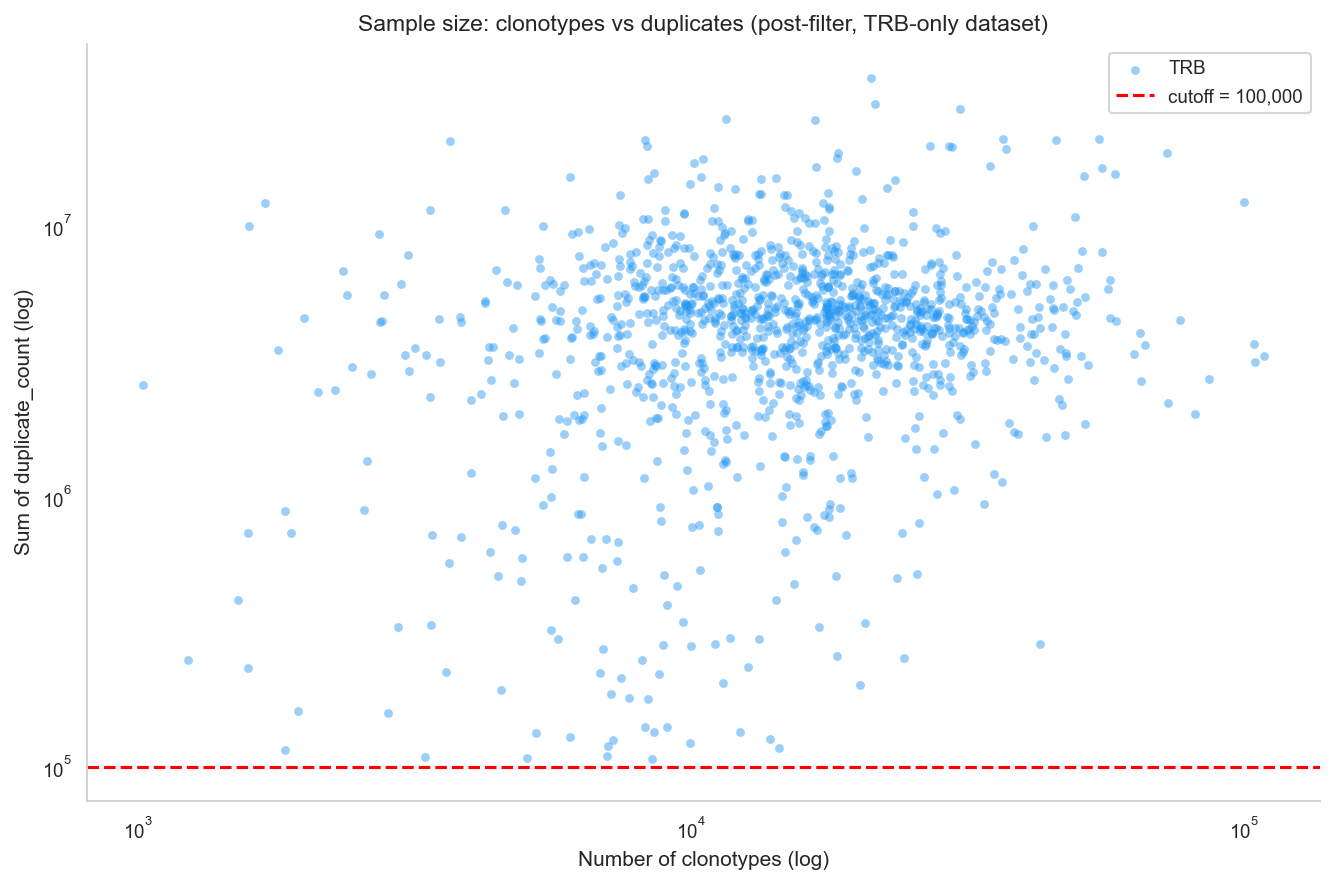

Samples shown: 1258, loci: ['TRB']
Median n_clonotypes (TRB): 15162
Median total_duplicates (TRB): 4478684


In [5]:
# Log-log scatter: sum(duplicate_count) vs number of clonotypes per sample.
# Approx runtime: <10s once dataset is loaded in memory.

scatter_rows = []
for sid, srep in dataset.samples.items():
    for loc, lr in srep.loci.items():
        n_clones = lr.clonotype_count
        n_dups = lr.duplicate_count
        scatter_rows.append({'sample_id': sid, 'locus': loc, 'n_clonotypes': n_clones, 'total_duplicates': n_dups})

scatter_df = pd.DataFrame(scatter_rows)

fig, ax = plt.subplots(figsize=(9, 6))
palette = {'TRB': '#2196F3', 'TRA': '#FF5722'}
for loc, grp in scatter_df.groupby('locus'):
    ax.scatter(grp['n_clonotypes'], grp['total_duplicates'],
               label=loc, color=palette.get(loc, 'grey'), alpha=0.45, s=18, linewidths=0)

ax.axhline(MIN_DUPLICATE_COUNT, color='red', linestyle='--', linewidth=1.5,
           label=f'cutoff = {MIN_DUPLICATE_COUNT:,}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of clonotypes (log)')
ax.set_ylabel('Sum of duplicate_count (log)')
ax.set_title('Sample size: clonotypes vs duplicates (post-filter, TRB-only dataset)')
ax.legend(framealpha=0.8)
plt.tight_layout()
plt.show()

print(f'Samples shown: {scatter_df["sample_id"].nunique()}, loci: {sorted(scatter_df["locus"].unique())}')
print(f'Median n_clonotypes (TRB): {scatter_df[scatter_df["locus"]=="TRB"]["n_clonotypes"].median():.0f}')
print(f'Median total_duplicates (TRB): {scatter_df[scatter_df["locus"]=="TRB"]["total_duplicates"].median():.0f}')

In [6]:
def _gene_to_str(g):
    if isinstance(g, tuple):
        return '|'.join(map(str, g))
    return str(g)


HIST_BIN_WIDTH = 0.12
HEATMAP_CMAP = 'YlGnBu'
LOG_P_EPS = 1e-8


def _uniform_bins(values: list[pd.Series], width: float = HIST_BIN_WIDTH, min_bins: int = 18):
    arr = pd.concat(values, ignore_index=True) if values else pd.Series(dtype=float)
    arr = pd.to_numeric(arr, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if arr.empty:
        return np.linspace(-6.0, 0.0, min_bins + 1)
    lo = float(np.quantile(arr, 0.01))
    hi = float(np.quantile(arr, 0.99))
    if hi <= lo:
        lo -= width
        hi += width
    start = np.floor(lo / width) * width
    stop = np.ceil(hi / width) * width
    n = max(min_bins, int(np.ceil((stop - start) / width)))
    return np.linspace(start, stop, n + 1)


def _log_series(s: pd.Series, eps: float = LOG_P_EPS) -> pd.Series:
    x = pd.to_numeric(s, errors='coerce').replace([np.inf, -np.inf], np.nan)
    x = x.fillna(0.0).clip(lower=0.0)
    return pd.Series(np.log10(np.maximum(x.to_numpy(dtype=float), eps)), index=s.index)


def _zscore_columns(mat: pd.DataFrame) -> pd.DataFrame:
    mu = mat.mean(axis=0)
    sigma = mat.std(axis=0).replace(0, np.nan)
    z = (mat - mu) / sigma
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def _build_sample_matrix(df: pd.DataFrame, value_col: str, locus: str = 'TRB') -> pd.DataFrame:
    d = df[df['locus'] == locus].copy()
    d['gene_str'] = d['gene'].map(_gene_to_str)
    mat = d.pivot_table(index='sample_id', columns='gene_str', values=value_col, aggfunc='mean', fill_value=0.0)
    row_sum = mat.sum(axis=1).replace(0, np.nan)
    mat = mat.div(row_sum, axis=0).fillna(0.0)
    return mat


def _scaled(mat: pd.DataFrame) -> np.ndarray:
    return StandardScaler(with_mean=True, with_std=True).fit_transform(mat.values)


def _pca_df(mat: pd.DataFrame, metadata_df: pd.DataFrame, n_components: int = 2):
    Xs = _scaled(mat)
    pca = PCA(n_components=n_components, random_state=42)
    Z = pca.fit_transform(Xs)
    out = pd.DataFrame(Z, index=mat.index, columns=[f'PC{i+1}' for i in range(n_components)])
    out = out.merge(metadata_df[['sample_id', 'batch_id']], left_index=True, right_on='sample_id', how='left')
    out['explained_var_pc1'] = pca.explained_variance_ratio_[0]
    out['explained_var_pc2'] = pca.explained_variance_ratio_[1] if n_components > 1 else np.nan
    return out, pca


def _umap_df(mat: pd.DataFrame, metadata_df: pd.DataFrame, **umap_kw):
    if not HAS_UMAP:
        return None
    Xs = _scaled(mat)
    kw = dict(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    kw.update(umap_kw)
    Z = UMAPReducer(**kw).fit_transform(Xs)
    out = pd.DataFrame(Z, index=mat.index, columns=['UMAP1', 'UMAP2'])
    out = out.merge(metadata_df[['sample_id', 'batch_id']], left_index=True, right_on='sample_id', how='left')
    return out


def _batch_separability_metrics(embedding_df: pd.DataFrame, xy_cols=('PC1', 'PC2')) -> dict:
    lab = embedding_df['batch_id'].astype(str).values
    pts = embedding_df[list(xy_cols)].values
    uniq = pd.unique(lab)
    if len(uniq) < 2:
        return {'silhouette_batch': np.nan, 'kmeans_ari': np.nan, 'kmeans_nmi': np.nan}
    sil = silhouette_score(pts, lab)
    km = KMeans(n_clusters=len(uniq), random_state=42, n_init='auto').fit(pts)
    ari = adjusted_rand_score(lab, km.labels_)
    nmi = normalized_mutual_info_score(lab, km.labels_)
    return {'silhouette_batch': sil, 'kmeans_ari': ari, 'kmeans_nmi': nmi}


HIGHLIGHT_GENES = ['TRBV6-2', 'TRBV6-3', 'TRBV28', 'TRBV4-3']


def _base_gene_name(gene_str: str) -> str:
    return str(gene_str).upper().split('*')[0]

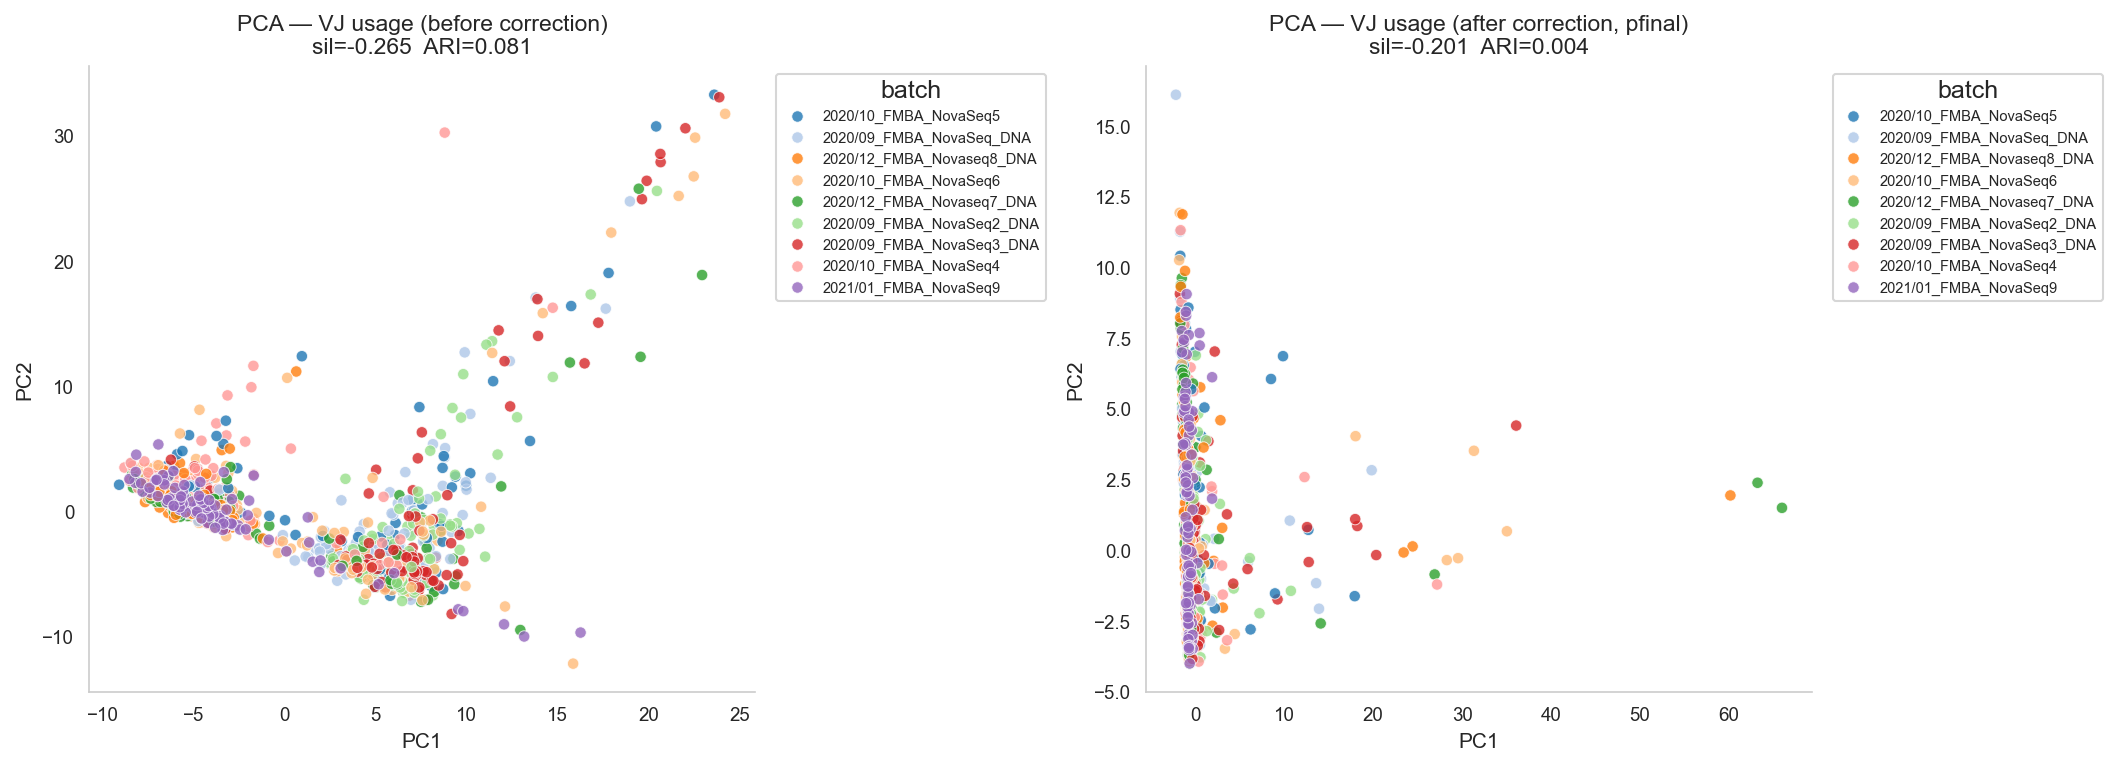

Batch separability — before: {'silhouette_batch': -0.2645269919504054, 'kmeans_ari': 0.08059954775273068, 'kmeans_nmi': 0.15313607986532013}
Batch separability — after : {'silhouette_batch': -0.20072157716511577, 'kmeans_ari': 0.004412544558228515, 'kmeans_nmi': 0.020489346956224473}


/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


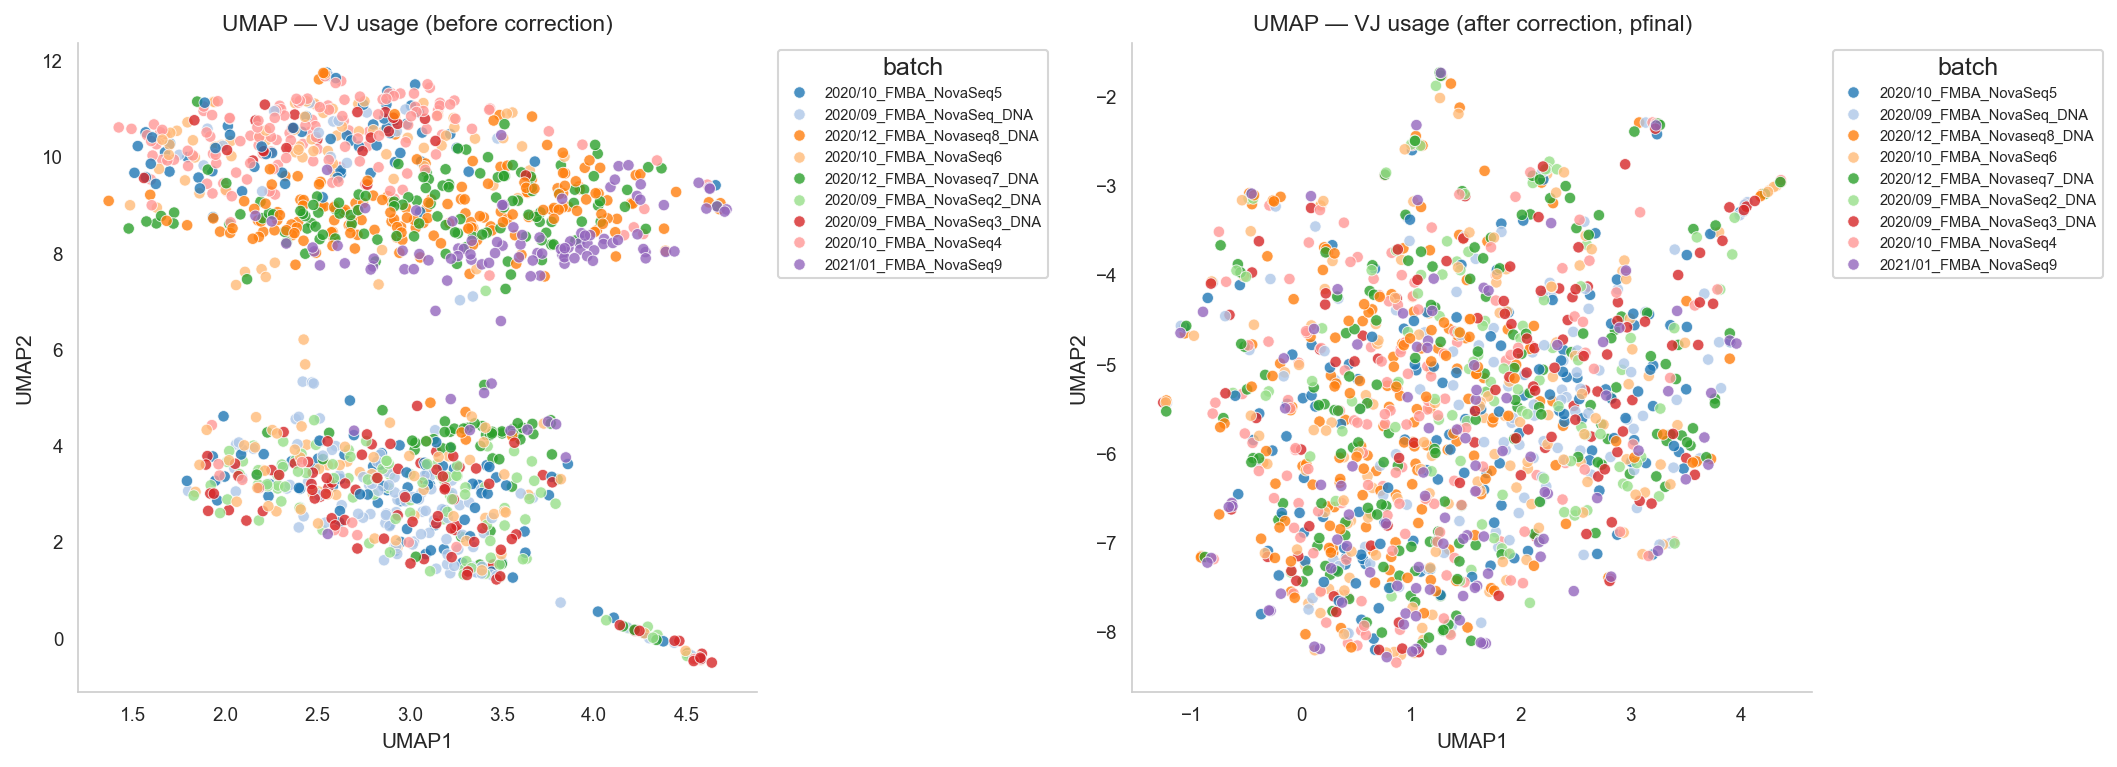

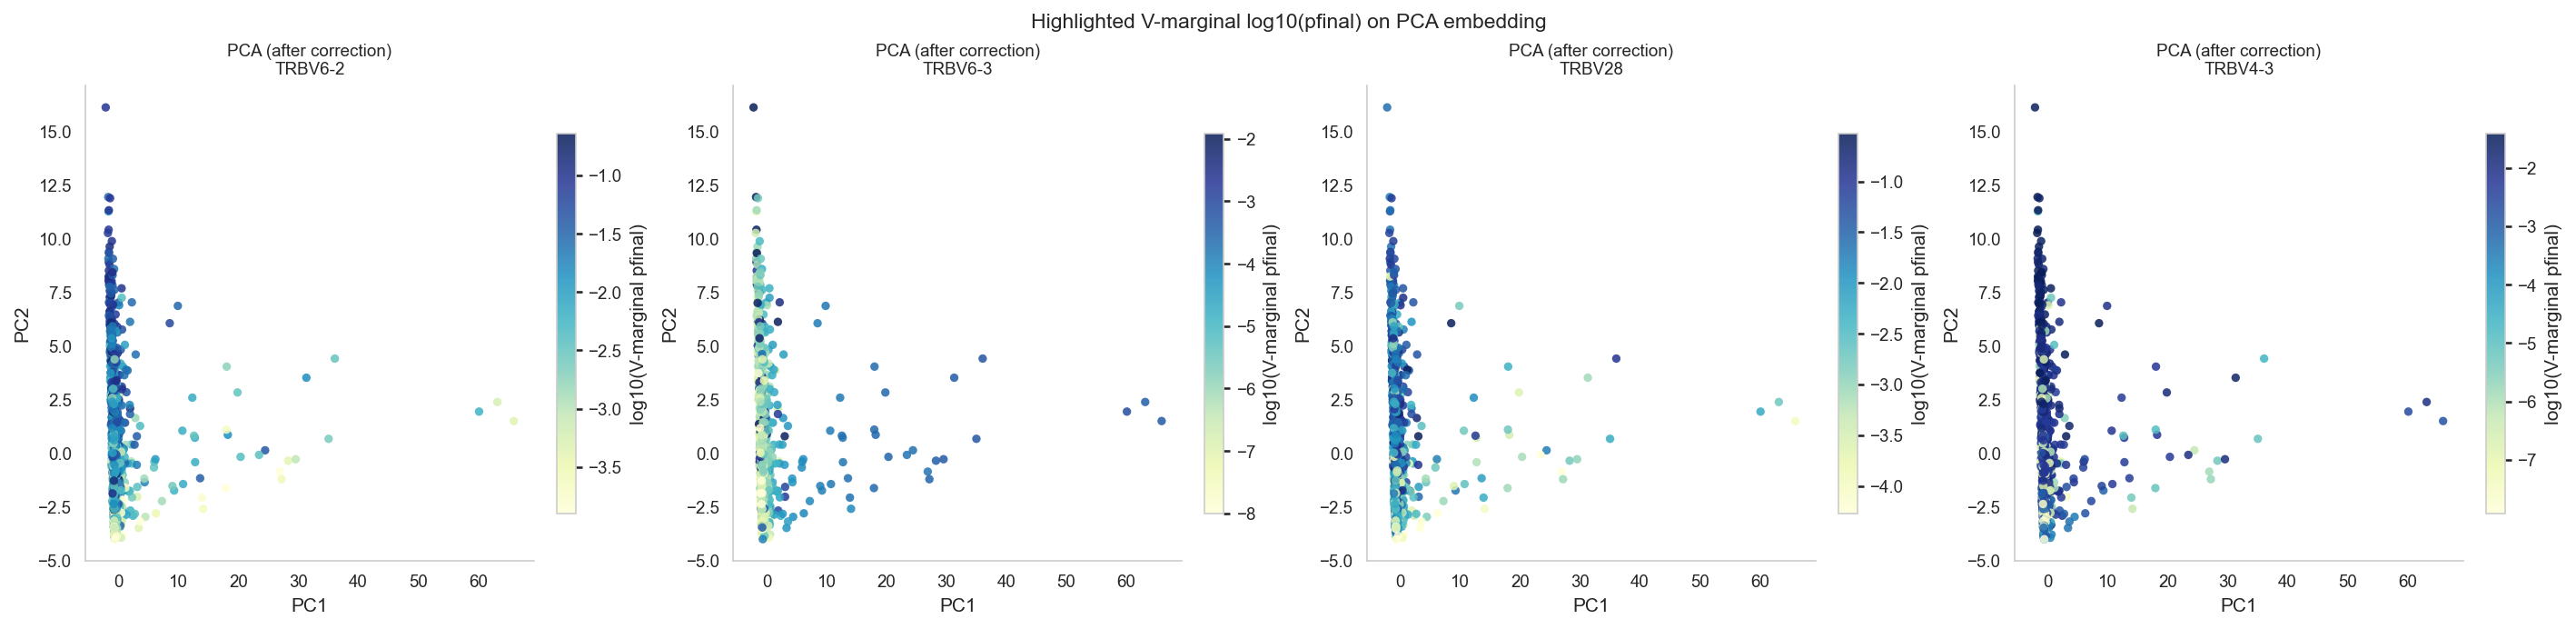

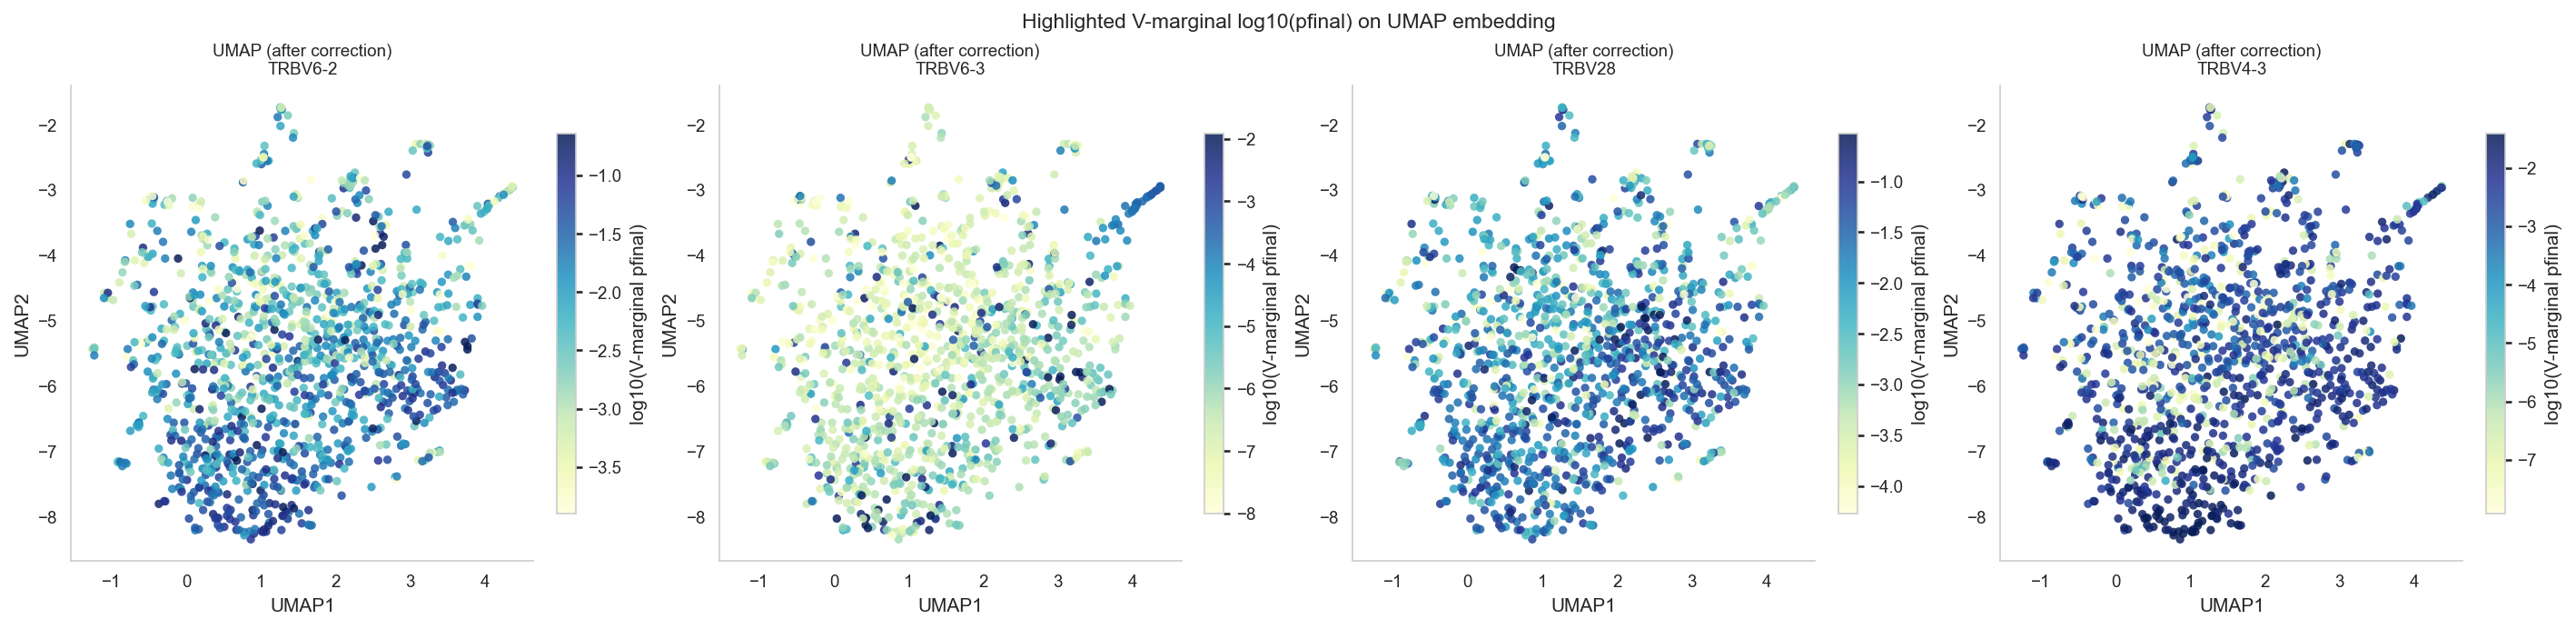

In [7]:
# --- Batch-corrected VJ usage for TRB ---
corr_vj = compute_batch_corrected_gene_usage(
    dataset, batch_field='batch_id', scope='vj', weighted=True, pseudocount=1.0, z_cap=6.0
)

meta_df = dataset.metadata_df.to_pandas() if hasattr(dataset.metadata_df, 'to_pandas') else dataset.metadata_df.reset_index(drop=True)

mat_before_vj = _build_sample_matrix(corr_vj, value_col='p', locus='TRB')
mat_after_vj   = _build_sample_matrix(corr_vj, value_col='pfinal', locus='TRB')

pca_before, _ = _pca_df(mat_before_vj, meta_df)
pca_after,  _ = _pca_df(mat_after_vj,  meta_df)

met_before = _batch_separability_metrics(pca_before)
met_after  = _batch_separability_metrics(pca_after)

# --- PCA scatter: batch coloring ---
n_batches = max(2, pca_before['batch_id'].nunique())
batch_palette = sns.color_palette('tab20', n_colors=n_batches)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.scatterplot(data=pca_before, x='PC1', y='PC2', hue='batch_id', ax=axes[0],
                palette=batch_palette, s=30, alpha=0.8)
axes[0].set_title(
    f'PCA — VJ usage (before correction)\n'
    f'sil={met_before["silhouette_batch"]:.3f}  ARI={met_before["kmeans_ari"]:.3f}'
)
axes[0].legend(title='batch', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

sns.scatterplot(data=pca_after, x='PC1', y='PC2', hue='batch_id', ax=axes[1],
                palette=batch_palette, s=30, alpha=0.8)
axes[1].set_title(
    f'PCA — VJ usage (after correction, pfinal)\n'
    f'sil={met_after["silhouette_batch"]:.3f}  ARI={met_after["kmeans_ari"]:.3f}'
)
axes[1].legend(title='batch', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.show()

print('Batch separability — before:', met_before)
print('Batch separability — after :', met_after)

# --- UMAP: batch coloring ---
umap_before = _umap_df(mat_before_vj, meta_df)
umap_after  = _umap_df(mat_after_vj,  meta_df)

if umap_before is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    sns.scatterplot(data=umap_before, x='UMAP1', y='UMAP2', hue='batch_id', ax=axes[0],
                    palette=batch_palette, s=30, alpha=0.8)
    axes[0].set_title('UMAP — VJ usage (before correction)')
    axes[0].legend(title='batch', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

    sns.scatterplot(data=umap_after, x='UMAP1', y='UMAP2', hue='batch_id', ax=axes[1],
                    palette=batch_palette, s=30, alpha=0.8)
    axes[1].set_title('UMAP — VJ usage (after correction, pfinal)')
    axes[1].legend(title='batch', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    plt.show()

# --- Highlighted V usage: marginalize VJ over J via module helper and color embeddings by log10(V usage) ---
v_marginal = marginalize_batch_corrected_gene_usage(
    corr_vj[corr_vj['locus'] == 'TRB'].copy(),
    scope='v',
)
v_marginal['gene_plot'] = v_marginal['gene'].map(_base_gene_name)

gene_wide = v_marginal.pivot_table(
    index='sample_id', columns='gene_plot', values='pfinal', aggfunc='mean', fill_value=0.0
)

available_highlights = [g for g in HIGHLIGHT_GENES if g in gene_wide.columns]

def _highlighted_scatter(embed_df, xy_cols, axes_row, title_prefix, cmap='YlGnBu'):
    for ax, gene in zip(axes_row, available_highlights):
        vals = gene_wide.loc[embed_df['sample_id'].values, gene].values if gene in gene_wide.columns else np.zeros(len(embed_df))
        log_vals = np.log10(np.maximum(vals.astype(float), LOG_P_EPS))
        vmin = np.percentile(log_vals, 2)
        vmax = np.percentile(log_vals, 98)
        if vmax <= vmin:
            vmax = vmin + 1e-6
        sc = ax.scatter(embed_df[xy_cols[0]], embed_df[xy_cols[1]],
                        c=log_vals, cmap=cmap, alpha=0.85, s=20, linewidths=0,
                        vmin=vmin, vmax=vmax)
        plt.colorbar(sc, ax=ax, shrink=0.8, label='log10(V-marginal pfinal)')
        ax.set_title(f'{title_prefix}\n{gene}', fontsize=9)
        ax.set_xlabel(xy_cols[0])
        ax.set_ylabel(xy_cols[1])

n_h = len(available_highlights)
if n_h > 0:
    pca_after_aligned = pca_after[pca_after['sample_id'].isin(gene_wide.index)].reset_index(drop=True)
    fig, axes = plt.subplots(1, n_h, figsize=(4.7 * n_h, 4.5), constrained_layout=True)
    if n_h == 1:
        axes = [axes]
    _highlighted_scatter(pca_after_aligned, ('PC1', 'PC2'), axes, 'PCA (after correction)', cmap='YlGnBu')
    fig.suptitle('Highlighted V-marginal log10(pfinal) on PCA embedding', fontsize=11)
    plt.show()

    if umap_after is not None:
        umap_aligned = umap_after[umap_after['sample_id'].isin(gene_wide.index)].reset_index(drop=True)
        fig, axes = plt.subplots(1, n_h, figsize=(4.7 * n_h, 4.5), constrained_layout=True)
        if n_h == 1:
            axes = [axes]
        _highlighted_scatter(umap_aligned, ('UMAP1', 'UMAP2'), axes, 'UMAP (after correction)', cmap='YlGnBu')
        fig.suptitle('Highlighted V-marginal log10(pfinal) on UMAP embedding', fontsize=11)
        plt.show()

### Runtime note & note on batch effect

The remaining embedding/correlation summary section is usually **1-3 minutes** on 401 TRB samples.

If rerunning repeatedly, keep earlier data-loading cells executed to avoid re-parse overhead.

Note that while batch effect vanishes after correction, true biological differences - bimodality in some V gene usage known from literature - do not

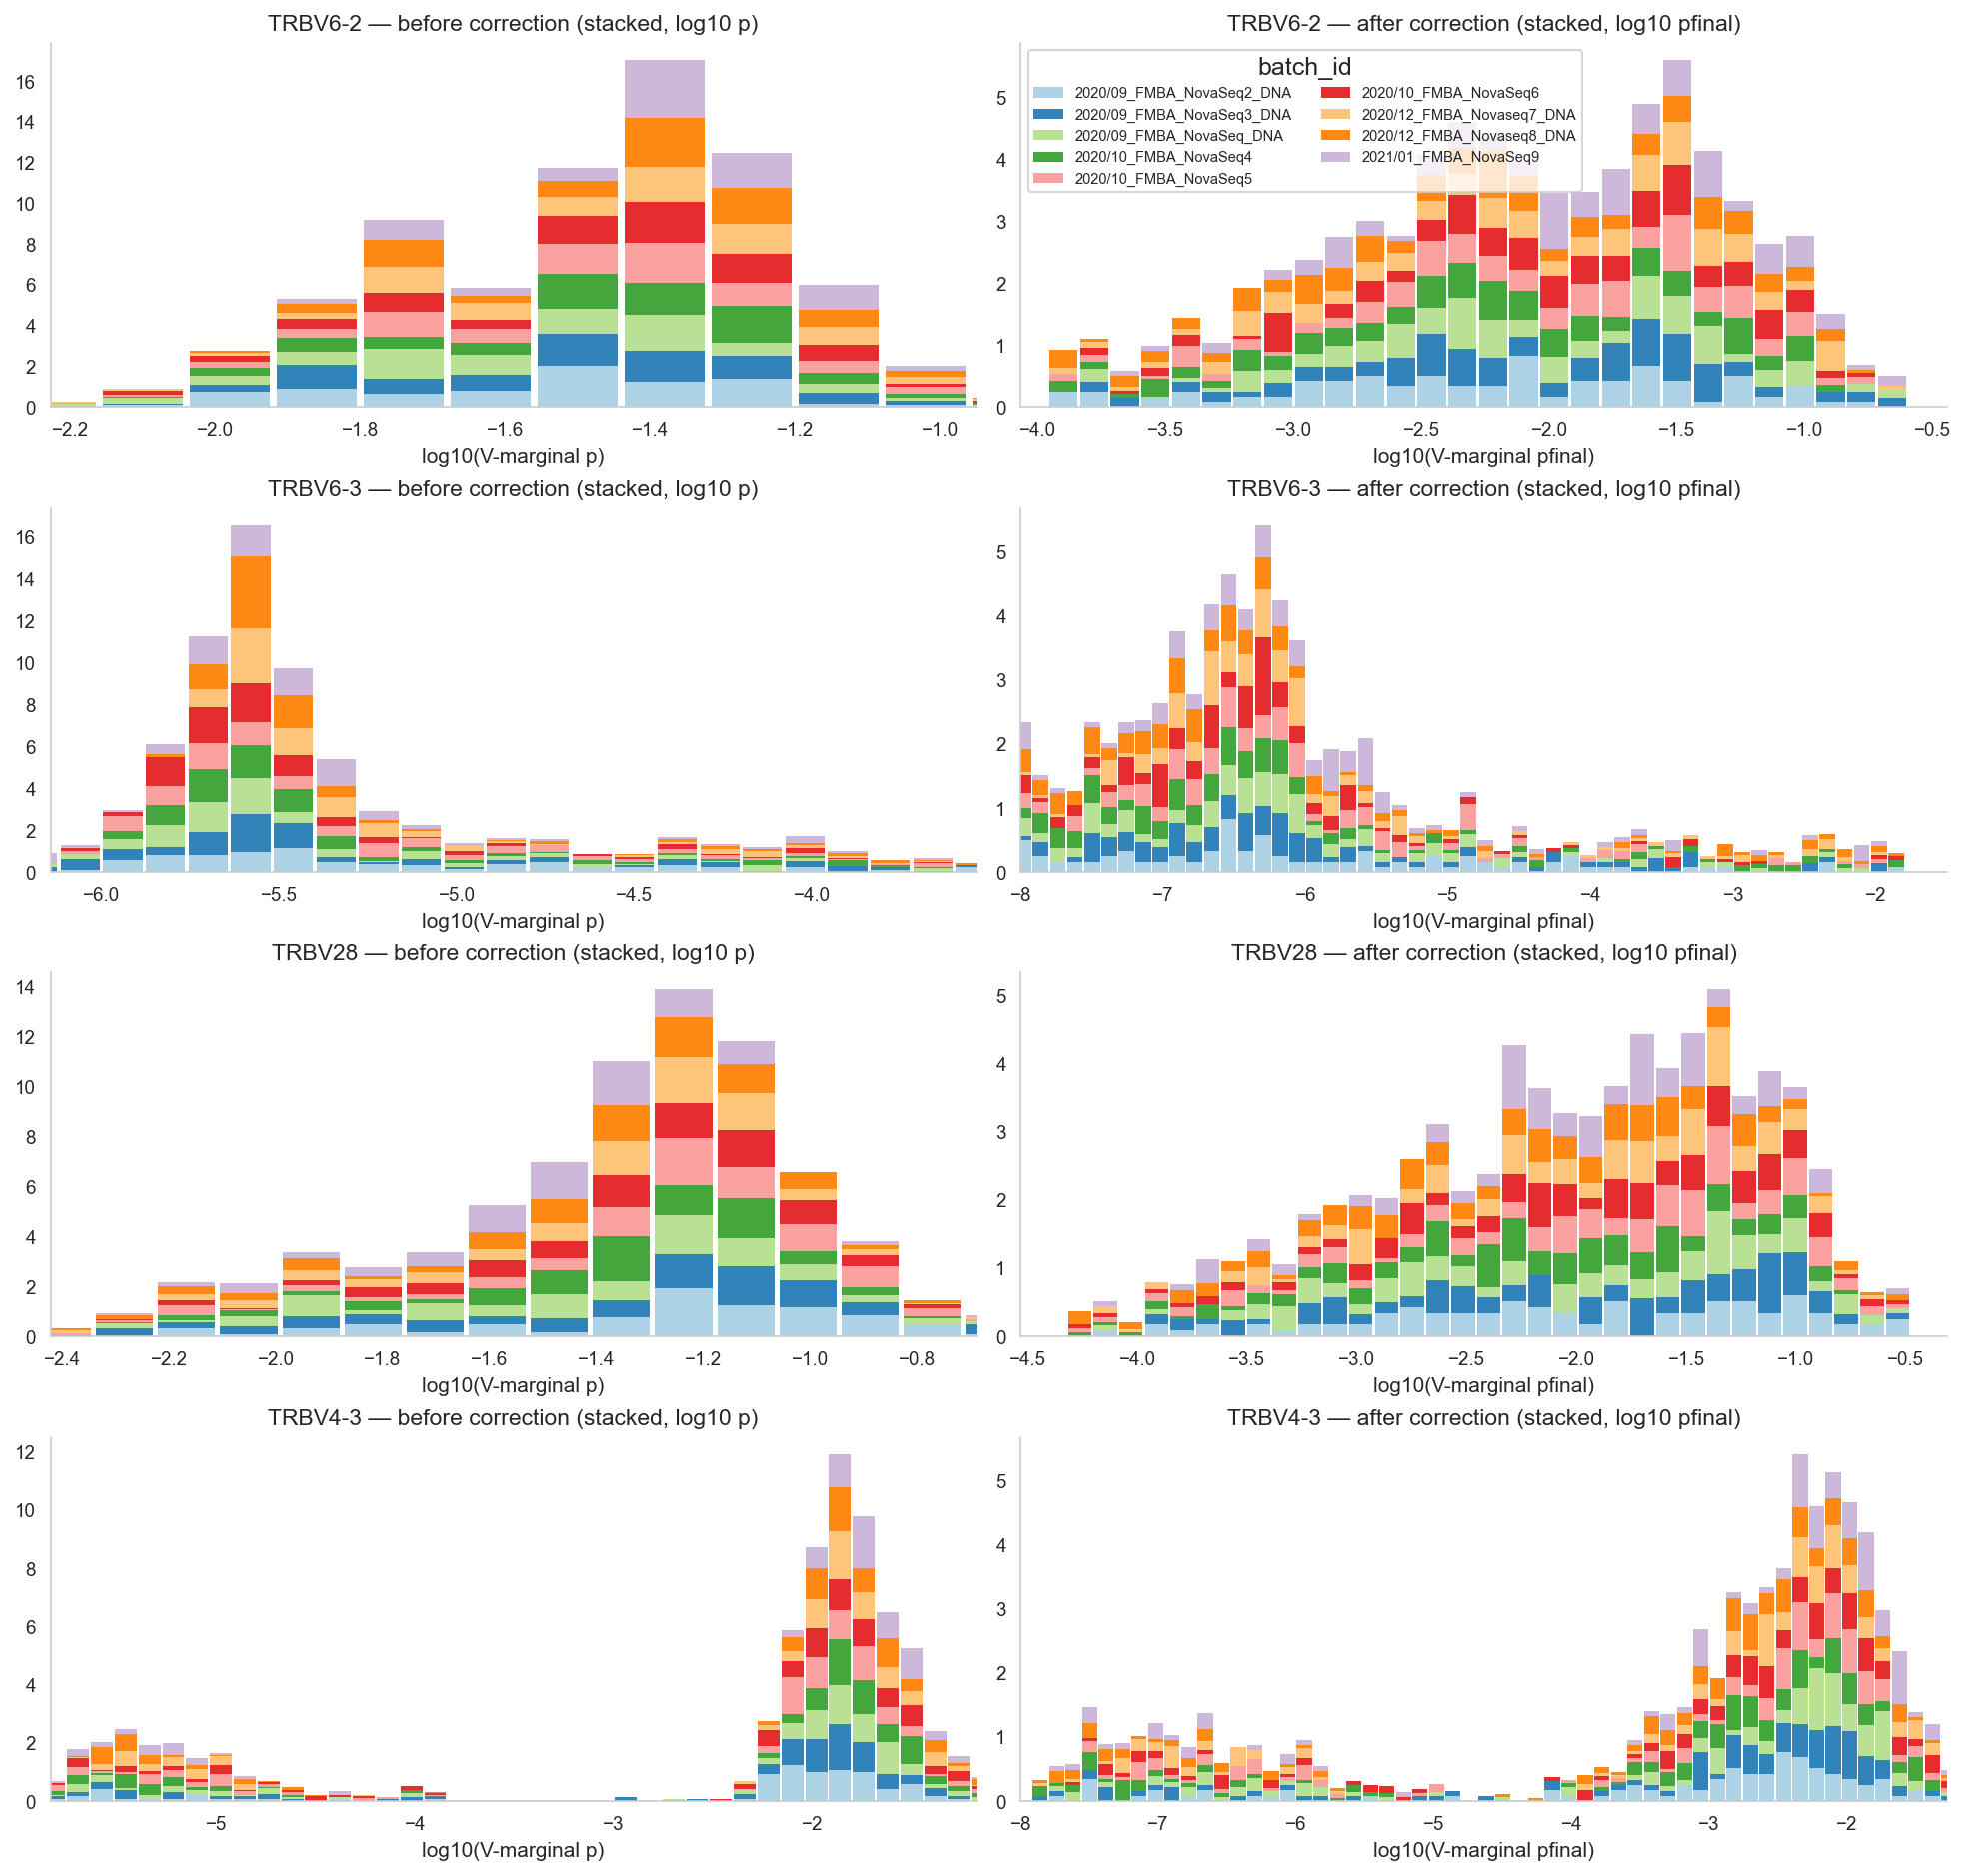

In [8]:
# Stacked barplots for highlighted TRB V-genes: before vs after correction on log10 scale.
# Uses module-level V-marginal usage derived from VJ table (sum over J).

corr_v_plot = v_marginal.copy()
if 'gene_plot' not in corr_v_plot.columns:
    corr_v_plot['gene_plot'] = corr_v_plot['gene'].map(_base_gene_name)

if 'batch_id' not in corr_v_plot.columns:
    corr_v_plot = corr_v_plot.merge(meta_df[['sample_id', 'batch_id']], on='sample_id', how='left')

plot_genes = [g for g in HIGHLIGHT_GENES if g in corr_v_plot['gene_plot'].unique()]
if not plot_genes:
    top_var = corr_v_plot.groupby('gene_plot')['p'].var().sort_values(ascending=False)
    plot_genes = list(top_var.head(4).index)

batch_levels = sorted(corr_v_plot['batch_id'].astype(str).unique())
batch_palette = dict(zip(batch_levels, sns.color_palette('Paired', n_colors=len(batch_levels))))

n_g = len(plot_genes)
fig, axes = plt.subplots(n_g, 2, figsize=(13, 3.1 * n_g), constrained_layout=True)
if n_g == 1:
    axes = np.array([axes])

for i, g in enumerate(plot_genes):
    d = corr_v_plot[corr_v_plot['gene_plot'] == g].copy()
    d['batch_id'] = d['batch_id'].astype(str)
    d['log10_p'] = _log_series(d['p'])
    d['log10_pfinal'] = _log_series(d['pfinal'])

    bins = _uniform_bins([d['log10_p'], d['log10_pfinal']], width=HIST_BIN_WIDTH)
    centers = (bins[:-1] + bins[1:]) / 2
    width = (bins[1] - bins[0]) * 0.92

    stacked_before = np.zeros(len(centers))
    for b in batch_levels:
        vals = d.loc[d['batch_id'] == b, 'log10_p'].dropna().values
        hist, _ = np.histogram(vals, bins=bins, density=True)
        axes[i, 0].bar(centers, hist, bottom=stacked_before, width=width, color=batch_palette[b], alpha=0.92, edgecolor='none', label=b if i == 0 else None)
        stacked_before += hist
    axes[i, 0].set_title(f'{g} — before correction (stacked, log10 p)')
    axes[i, 0].set_xlabel('log10(V-marginal p)')
    axes[i, 0].set_xlim(float(np.quantile(d['log10_p'], 0.01)), float(np.quantile(d['log10_p'], 0.99)))

    stacked_after = np.zeros(len(centers))
    for b in batch_levels:
        vals = d.loc[d['batch_id'] == b, 'log10_pfinal'].dropna().values
        hist, _ = np.histogram(vals, bins=bins, density=True)
        axes[i, 1].bar(centers, hist, bottom=stacked_after, width=width, color=batch_palette[b], alpha=0.92, edgecolor='none', label=b if i == 0 else None)
        stacked_after += hist
    axes[i, 1].set_title(f'{g} — after correction (stacked, log10 pfinal)')
    axes[i, 1].set_xlabel('log10(V-marginal pfinal)')
    axes[i, 1].set_xlim(float(np.quantile(d['log10_pfinal'], 0.01)), float(np.quantile(d['log10_pfinal'], 0.99)))

if n_g > 0:
    axes[0, 1].legend(title='batch_id', fontsize=7, ncol=2, frameon=True)

plt.show()

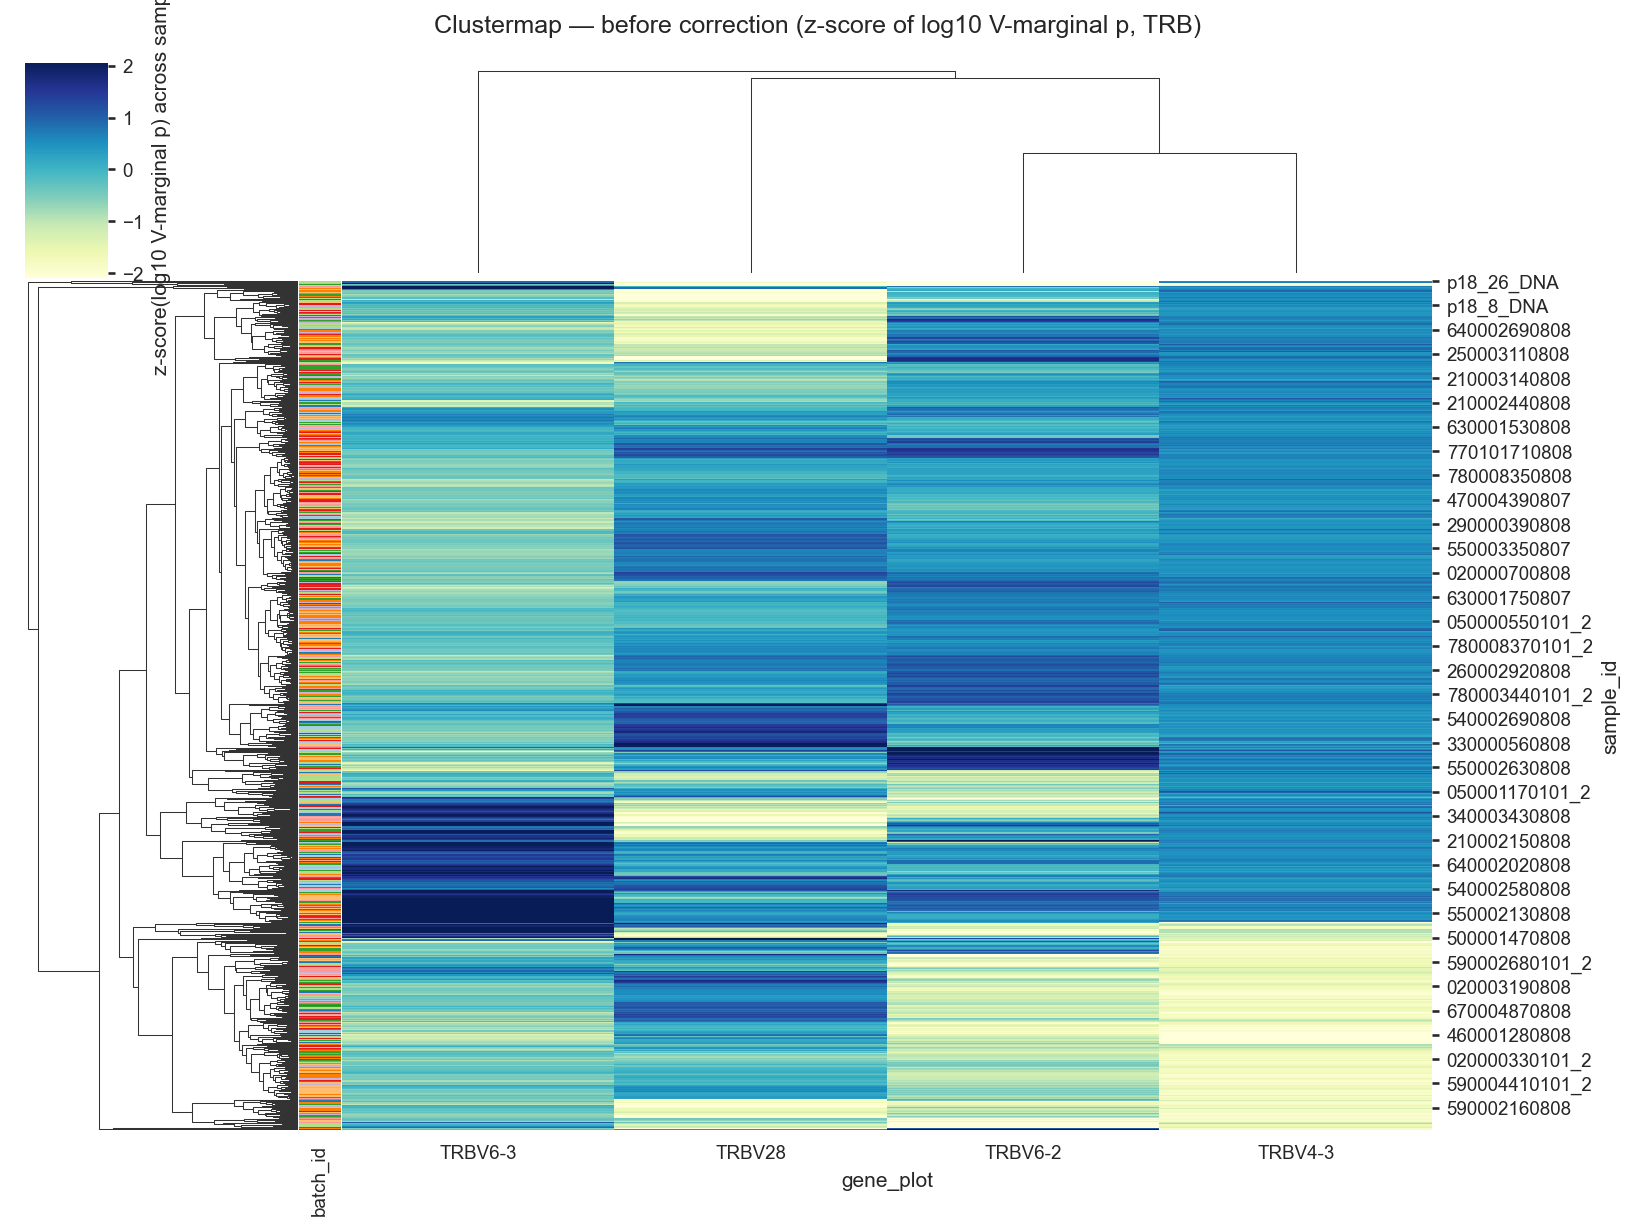

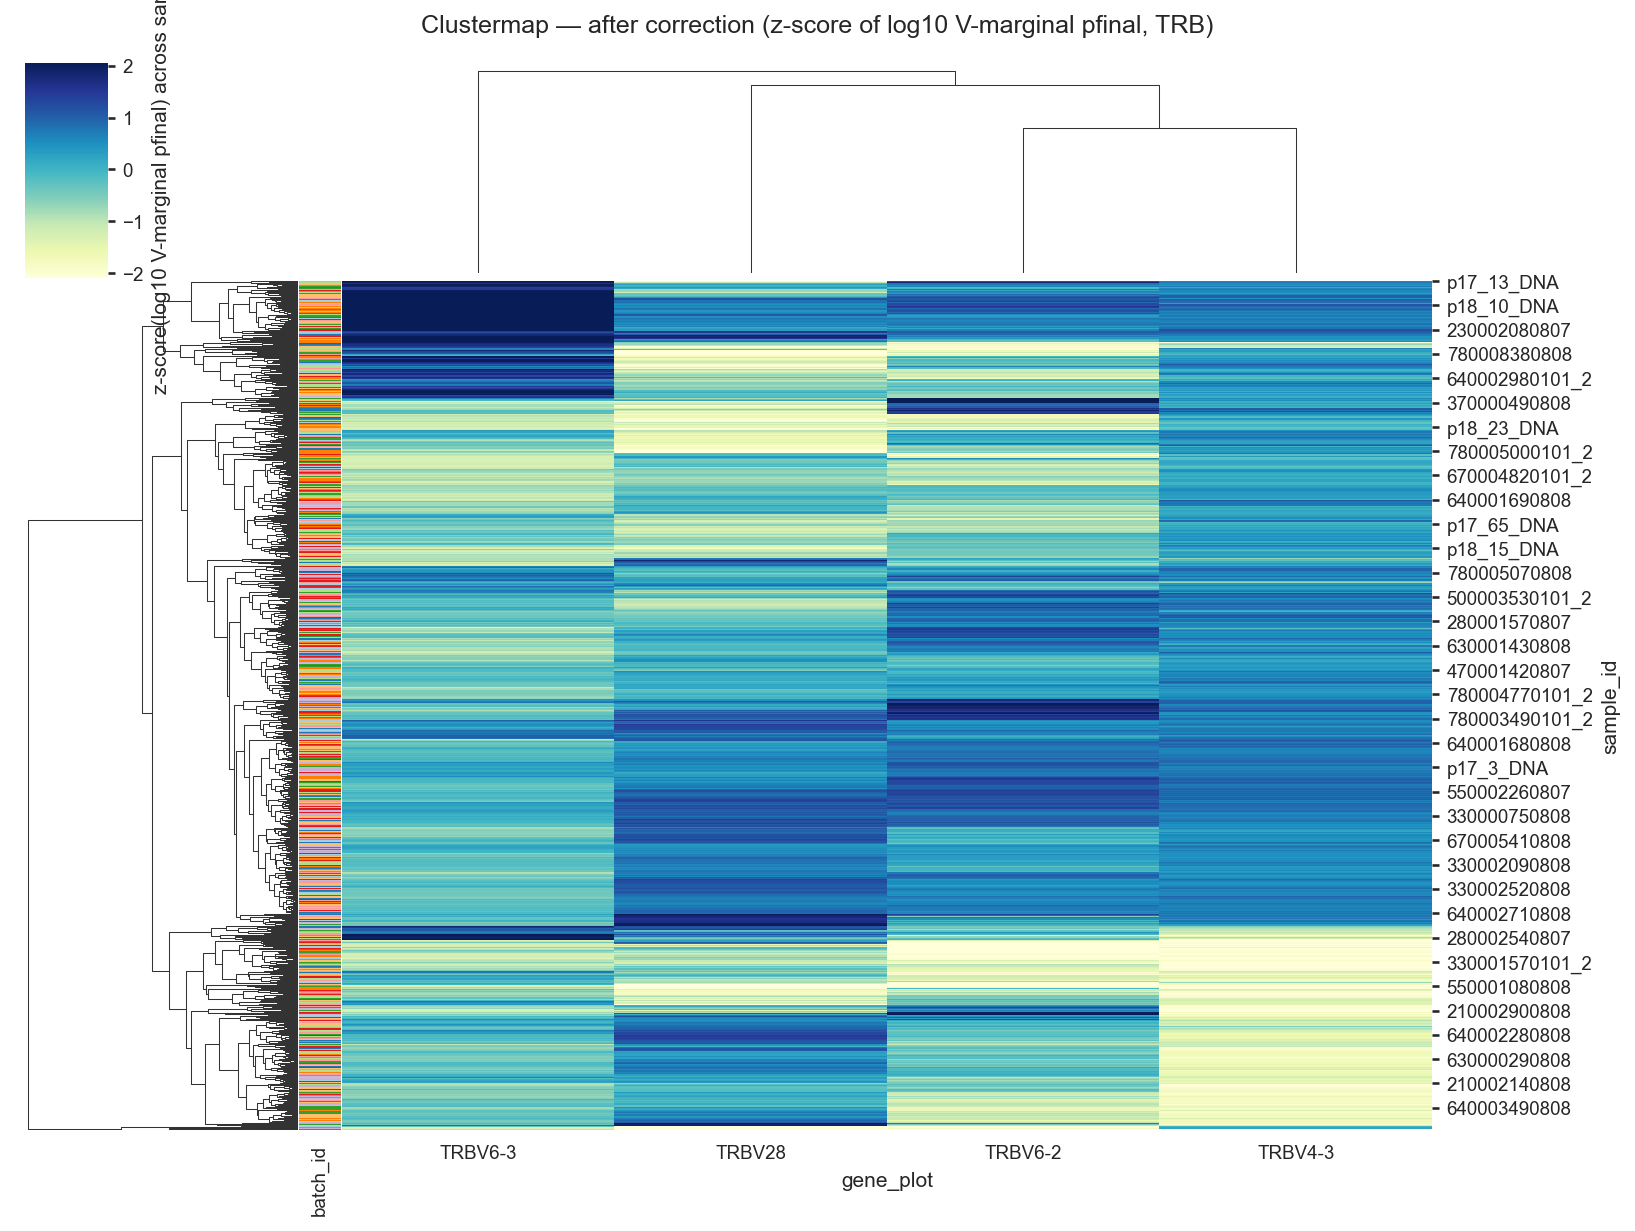

In [9]:
# Clustermap: highlighted V-gene usage before and after correction (TRB only),
# fill = log10(V-marginal usage), normalized by z-scoring across columns.
before_v = corr_v_plot.pivot_table(index='sample_id', columns='gene_plot', values='p', aggfunc='mean', fill_value=0.0)
after_v  = corr_v_plot.pivot_table(index='sample_id', columns='gene_plot', values='pfinal', aggfunc='mean', fill_value=0.0)

available_h = [g for g in HIGHLIGHT_GENES if g in before_v.columns]
if not available_h:
    available_h = list(before_v.var(axis=0).sort_values(ascending=False).head(20).index)

before_log = np.log10(np.maximum(before_v[available_h], LOG_P_EPS))
after_log  = np.log10(np.maximum(after_v[available_h], LOG_P_EPS))
before_h = _zscore_columns(before_log)
after_h  = _zscore_columns(after_log)

batch_series = meta_df.set_index('sample_id').loc[before_h.index, 'batch_id'].astype(str)
batch_levels = sorted(batch_series.unique())
batch_palette = dict(zip(batch_levels, sns.color_palette('Paired', n_colors=len(batch_levels))))
row_colors = batch_series.map(batch_palette)

vmin = float(np.nanquantile(pd.concat([before_h.stack(), after_h.stack()]), 0.02))
vmax = float(np.nanquantile(pd.concat([before_h.stack(), after_h.stack()]), 0.98))
if vmax <= vmin:
    vmax = vmin + 1e-6

sns.clustermap(
    before_h,
    cmap=HEATMAP_CMAP,
    row_colors=row_colors,
    figsize=(11, 8),
    vmin=vmin,
    vmax=vmax,
    cbar_kws={'label': 'z-score(log10 V-marginal p) across samples'},
)
plt.suptitle('Clustermap — before correction (z-score of log10 V-marginal p, TRB)', y=1.02)
plt.show()

sns.clustermap(
    after_h,
    cmap=HEATMAP_CMAP,
    row_colors=row_colors,
    figsize=(11, 8),
    vmin=vmin,
    vmax=vmax,
    cbar_kws={'label': 'z-score(log10 V-marginal pfinal) across samples'},
)
plt.suptitle('Clustermap — after correction (z-score of log10 V-marginal pfinal, TRB)', y=1.02)
plt.show()

Resampled:           1258 samples
Resampled+filtered:  1258 samples


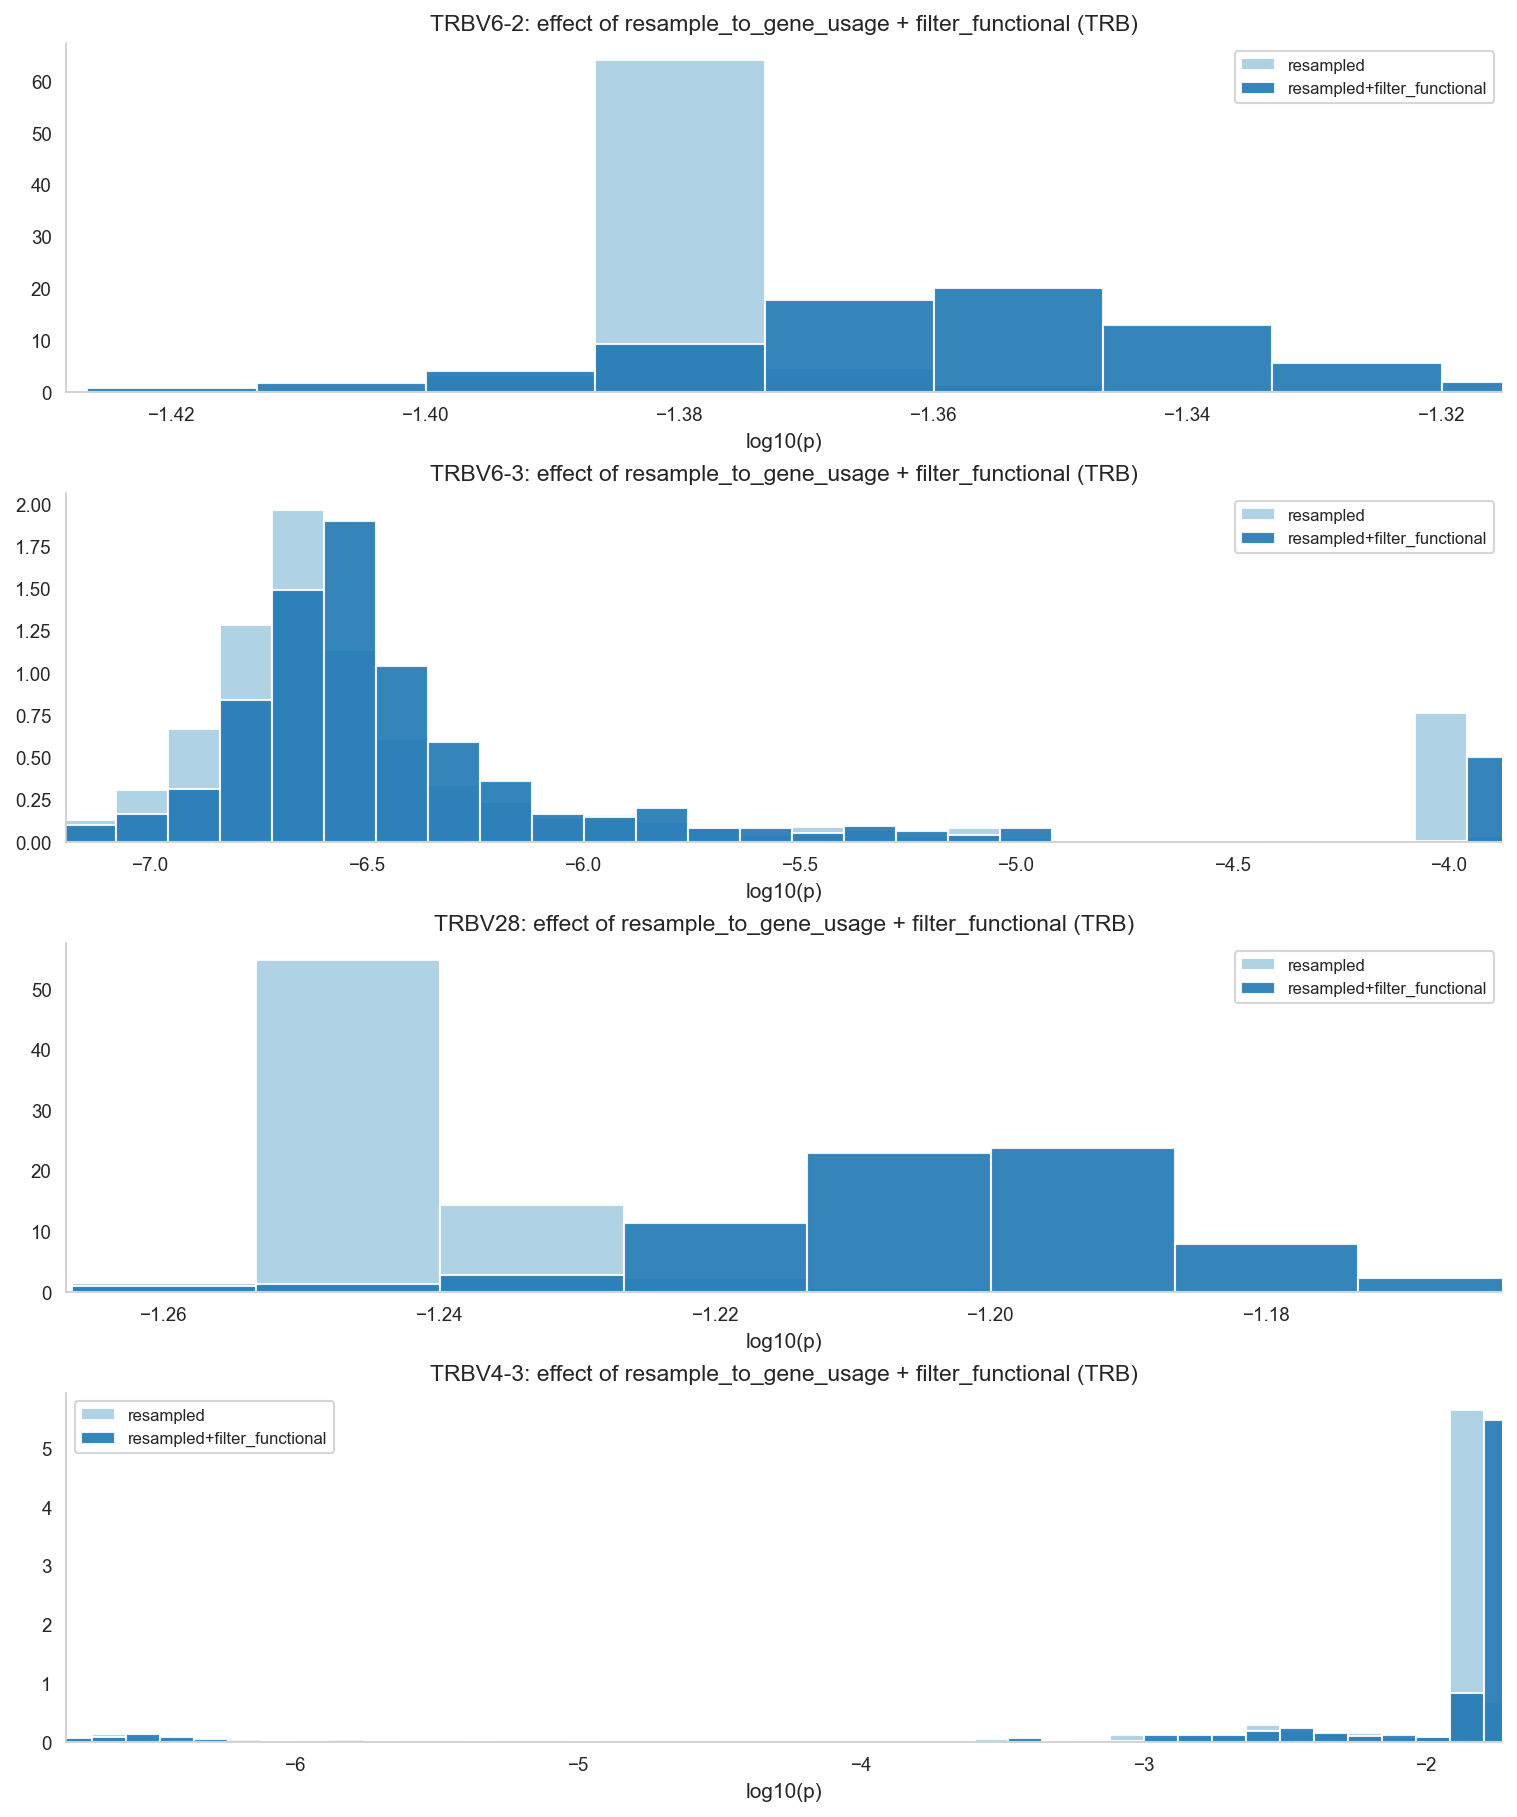


=== Final TRB cohort statistics ===
Samples: 1258
Batches: 9
Total clonotypes: 22,299,806
Total duplicates: 6,168,685,332


(        sample_id                   batch_id  n_loci  n_clonotypes  \
 0    020000010808      2020/10_FMBA_NovaSeq5       1          4324   
 1    020000280808      2020/10_FMBA_NovaSeq5       1          6144   
 2  020000330101_2  2020/12_FMBA_Novaseq8_DNA       1         10762   
 3    020000340808      2020/10_FMBA_NovaSeq5       1          7386   
 4    020000200808      2020/10_FMBA_NovaSeq5       1         14220   
 
    n_duplicates  
 0        623811  
 1       2005779  
 2       4558846  
 3       6526027  
 4       6583555  ,
                            n_samples  n_clonotypes  n_duplicates
 batch_id                                                        
 2020/12_FMBA_Novaseq8_DNA        185       3543328     793224885
 2020/12_FMBA_Novaseq7_DNA        175       3517861     634554645
 2020/10_FMBA_NovaSeq4            158       2868924     788275450
 2020/10_FMBA_NovaSeq6            151       2271918     788512300
 2020/10_FMBA_NovaSeq5            147       2093100     67827

In [10]:
# --- Resampling to pooled VJ target + functional filtering ---
# Approx runtime: 20-60s for ~1200 TRB samples depending on clone counts.
target_scale = 10_000
target_vj_usage = {
    row['gene']: max(1, int(round(float(row['pavg']) * target_scale)))
    for _, row in (
        corr_vj[corr_vj['locus'] == 'TRB']
        .drop_duplicates('gene')[['gene', 'pavg']]
        .iterrows()
    )
}

resampled_samples = {}
resampled_filtered_samples = {}

for sid, srep in dataset.samples.items():
    if 'TRB' not in srep.loci:
        continue
    trb_resampled = resample_to_gene_usage(
        srep.loci['TRB'], target_vj_usage, scope='vj', weighted=True, random_seed=42,
    )
    s_res = type(srep)(loci={'TRB': trb_resampled}, sample_id=sid, sample_metadata=dict(srep.sample_metadata))
    resampled_samples[sid] = s_res
    resampled_filtered_samples[sid] = filter_functional(s_res)

dataset_resampled = RepertoireDataset(samples=resampled_samples)
dataset_resampled_filtered = RepertoireDataset(samples=resampled_filtered_samples)

print(f'Resampled:           {len(dataset_resampled.samples)} samples')
print(f'Resampled+filtered:  {len(dataset_resampled_filtered.samples)} samples')

# V-gene distributions after resampling and functional filtering.
corr_res_v = compute_batch_corrected_gene_usage(
    dataset_resampled, batch_field='batch_id', scope='v', weighted=True
)
corr_res_v['gene_plot'] = corr_res_v['gene'].map(_base_gene_name)

corr_resf_v = compute_batch_corrected_gene_usage(
    dataset_resampled_filtered, batch_field='batch_id', scope='v', weighted=True
)
corr_resf_v['gene_plot'] = corr_resf_v['gene'].map(_base_gene_name)

dist_comp = pd.concat([
    corr_res_v.assign(dataset='resampled'),
    corr_resf_v.assign(dataset='resampled+filter_functional'),
], ignore_index=True)

genes_to_show = [g for g in HIGHLIGHT_GENES if g in set(dist_comp['gene_plot'])]
if not genes_to_show:
    genes_to_show = sorted(dist_comp['gene_plot'].unique())[:4]

palette_final = {'resampled': sns.color_palette('Paired', 2)[0], 'resampled+filter_functional': sns.color_palette('Paired', 2)[1]}

n_g = len(genes_to_show)
fig, axes = plt.subplots(n_g, 1, figsize=(10, 3.0 * n_g), constrained_layout=True)
if n_g == 1:
    axes = [axes]

for ax, g in zip(axes, genes_to_show):
    d = dist_comp[dist_comp['gene_plot'] == g].copy()
    d['log10_p'] = _log_series(d['p'])
    bins = _uniform_bins([d['log10_p']], width=HIST_BIN_WIDTH)
    x_lo = float(np.quantile(d['log10_p'], 0.01))
    x_hi = float(np.quantile(d['log10_p'], 0.99))
    for ds_name, grp in d.groupby('dataset', sort=False):
        vals = pd.to_numeric(grp['log10_p'], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=bins, density=True, alpha=0.9, label=str(ds_name), color=palette_final.get(str(ds_name), '#4C72B0'))
    ax.set_title(f'{g}: effect of resample_to_gene_usage + filter_functional (TRB)')
    ax.set_xlabel('log10(p)')
    ax.set_xlim(x_lo, x_hi)
    ax.legend(fontsize=8)

plt.show()

# --- Final cohort statistics ---
sample_rows = []
for sid, srep in dataset.samples.items():
    n_clones = srep.clonotype_count
    n_dups = srep.duplicate_count
    sample_rows.append({
        'sample_id': sid,
        'batch_id':  str(dataset.metadata[sid].get('batch_id', 'NA')),
        'n_loci':    len(srep.loci),
        'n_clonotypes': n_clones,
        'n_duplicates': n_dups,
    })

stats_df = pd.DataFrame(sample_rows)
batch_stats = stats_df.groupby('batch_id').agg(
    n_samples=('sample_id', 'nunique'),
    n_clonotypes=('n_clonotypes', 'sum'),
    n_duplicates=('n_duplicates', 'sum'),
).sort_values('n_samples', ascending=False)

print('\n=== Final TRB cohort statistics ===')
print(f'Samples: {stats_df["sample_id"].nunique()}')
print(f'Batches: {stats_df["batch_id"].nunique()}')
print(f'Total clonotypes: {stats_df["n_clonotypes"].sum():,}')
print(f'Total duplicates: {stats_df["n_duplicates"].sum():,}')
stats_df.head(), batch_stats